In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset + display shape and head
df = pd.read_csv('hotel_bookings.csv')
print("Shape:", df.shape)  # should be (119390, 32)
df.head()

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


           count        pct
children       4   0.003350
country      488   0.408744
agent      16340  13.686238
company   112593  94.306893


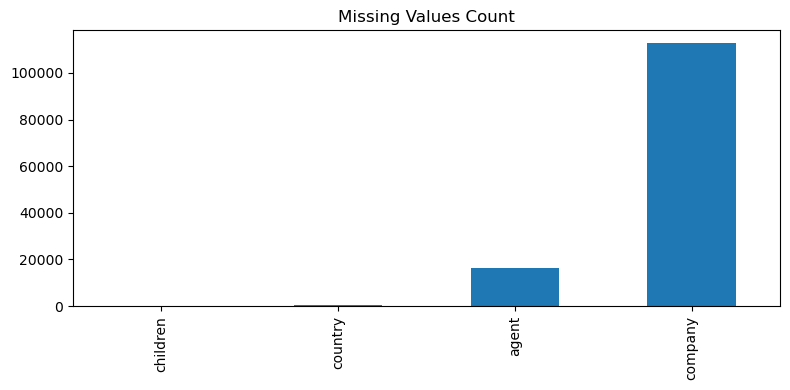

In [2]:
# 2. Show and visualise missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
print(pd.DataFrame({'count': missing, 'pct': missing_pct})[lambda x: x['count']>0])

missing[missing > 0].plot(kind='bar', figsize=(8,4), title='Missing Values Count')
plt.tight_layout()
plt.show()

In [3]:
# 3. Handle missing values — same decisions in all 4 notebooks
df.drop(columns=['company'], inplace=True)          # 94.3% missing — unusable
df['children'].fillna(0, inplace=True)              # missing = no children
df['agent'].fillna(0, inplace=True)                 # missing = no agent used
df['country'].fillna(df['country'].mode()[0], inplace=True)  # fill with most common
assert df.isnull().sum().sum() == 0                 # verify zero nulls remain

C:\Users\mahim\AppData\Local\Temp\ipykernel_48160\3387597147.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(0, inplace=True)              # missing = no children
C:\Users\mahim\AppData\Local\Temp\ipykernel_48160\3387597147.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

In [4]:
# 4. Remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {before - len(df)} duplicate rows. Remaining: {len(df)}")

Removed 32020 duplicate rows. Remaining: 87370


In [5]:
# 5. Remove data leakage columns
# reservation_status directly reveals the target
df.drop(columns=['reservation_status', 'reservation_status_date'], inplace=True)

In [6]:
# 6. Remove invalid and outlier rows
df = df[df['adr'] >= 0]                                          # remove negative ADR
df = df[df['adr'] < 1000]                                        # remove extreme outliers
df = df[(df['adults']+df['children']+df['babies']) > 0]          # remove 0-guest rows
print("Rows after cleaning:", len(df))

Rows after cleaning: 87202


In [7]:
# 7. Correlation analysis — show which features are most relevant to is_canceled
corr = df.select_dtypes('number').corr()['is_canceled'].abs().sort_values(ascending=False)
print(corr.head(10))

is_canceled                    1.000000
required_car_parking_spaces    0.184519
lead_time                      0.184423
adr                            0.132674
total_of_special_requests      0.120844
booking_changes                0.093303
is_repeated_guest              0.088777
arrival_date_year              0.088029
stays_in_week_nights           0.084075
adults                         0.080129
Name: is_canceled, dtype: float64


In [8]:
# 8. Define X and y — IDENTICAL split in all 4 notebooks
# IMPORTANT: random_state=42 and stratify=y MUST be the same in all 4 notebooks
from sklearn.model_selection import train_test_split

X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
top_countries = X_train['country'].value_counts().nlargest(10).index
X_train['country'] = X_train['country'].where(X_train['country'].isin(top_countries), 'Other')
X_test['country']  = X_test['country'].where(X_test['country'].isin(top_countries), 'Other')

In [10]:
# Feature engineering
# These new features help the model understand booking behaviour better
X_train['total_stay']   = X_train['stays_in_weekend_nights'] + X_train['stays_in_week_nights']
X_train['total_guests'] = X_train['adults'] + X_train['children'] + X_train['babies']
X_train['has_agent']    = (X_train['agent'] > 0).astype(int)

X_test['total_stay']    = X_test['stays_in_weekend_nights'] + X_test['stays_in_week_nights']
X_test['total_guests']  = X_test['adults'] + X_test['children'] + X_test['babies']
X_test['has_agent']     = (X_test['agent'] > 0).astype(int)

In [11]:
# One-hot encode all categorical columns

categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=True)

# Align columns — test may be missing some dummy columns after encoding
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("Final shape — X_train:", X_train.shape, "| X_test:", X_test.shape)

Categorical columns to encode: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
Final shape — X_train: (69761, 81) | X_test: (17441, 81)


In [12]:
# Gradient Boosting is a tree-based ensemble method.
# It splits on thresholds, not distances — feature scale does not affect splits.
# Therefore StandardScaler is NOT required for GradientBoostingClassifier.
print("No scaling applied — Gradient Boosting is scale-invariant (tree-based model).")

No scaling applied — Gradient Boosting is scale-invariant (tree-based model).


In [13]:
# Preprocessing summary cell
print("=== PREPROCESSING SUMMARY ===")
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Total features   : {X_train.shape[1]}")
print(f"Null values      : {X_train.isnull().sum().sum()}")
print(f"Class distribution (train):")
print(y_train.value_counts(normalize=True).rename({0:'Not Cancelled', 1:'Cancelled'}))

=== PREPROCESSING SUMMARY ===
Training samples : 69761
Test samples     : 17441
Total features   : 81
Null values      : 0
Class distribution (train):
is_canceled
Not Cancelled    0.724703
Cancelled        0.275297
Name: proportion, dtype: float64


### Algorithm Introduction:

##### Gradient Boosting builds an ensemble of decision trees SEQUENTIALLY.
##### Each new tree corrects the errors of the previous one by fitting on residuals.
##### It uses gradient descent in function space to minimise a loss function (log-loss for classification).
##### Key hyperparameters:
#####   - n_estimators: number of trees (more = better but slower)
#####   - learning_rate: shrinks each tree's contribution (lower = more robust, needs more trees)
#####   - max_depth: depth of each individual tree (controls overfitting)
##### GB is powerful for tabular data and handles class imbalance well with class_weight.


In [14]:
# ============================================================
# GRADIENT BOOSTING — MODEL TRAINING
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Handle class imbalance

gb_model = GradientBoostingClassifier(
    n_estimators=200,        # 200 trees for good accuracy
    learning_rate=0.1,       # standard starting point
    max_depth=4,             # shallow trees to avoid overfitting
    subsample=0.8,           # stochastic GB — uses 80% of data per tree (reduces overfitting)
    random_state=42          # reproducibility
)

# Note: GradientBoostingClassifier does not support class_weight directly.
# We handle imbalance using sample_weight instead:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print("Training Gradient Boosting model... (this may take 1-2 minutes)")
gb_model.fit(X_train, y_train, sample_weight=sample_weights)
print("Training complete.")

Training Gradient Boosting model... (this may take 1-2 minutes)
Training complete.


In [15]:
# ============================================================
# RESULTS AND EVALUATION
# ============================================================

y_pred  = gb_model.predict(X_test)
y_proba = gb_model.predict_proba(X_test)[:, 1]

# Core metrics
acc      = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Cancelled', 'Cancelled']))

Accuracy : 0.8101
ROC-AUC  : 0.9112

Classification Report:
               precision    recall  f1-score   support

Not Cancelled       0.94      0.79      0.86     12639
    Cancelled       0.61      0.87      0.72      4802

     accuracy                           0.81     17441
    macro avg       0.77      0.83      0.79     17441
 weighted avg       0.85      0.81      0.82     17441



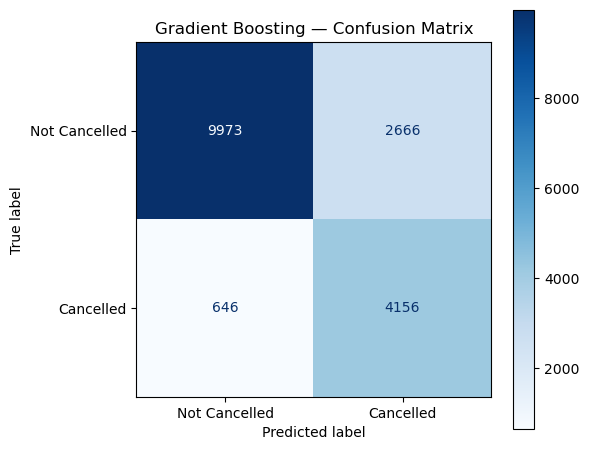

In [16]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=['Not Cancelled', 'Cancelled'],
    cmap='Blues', ax=ax)
plt.title('Gradient Boosting — Confusion Matrix')
plt.tight_layout()
plt.show()

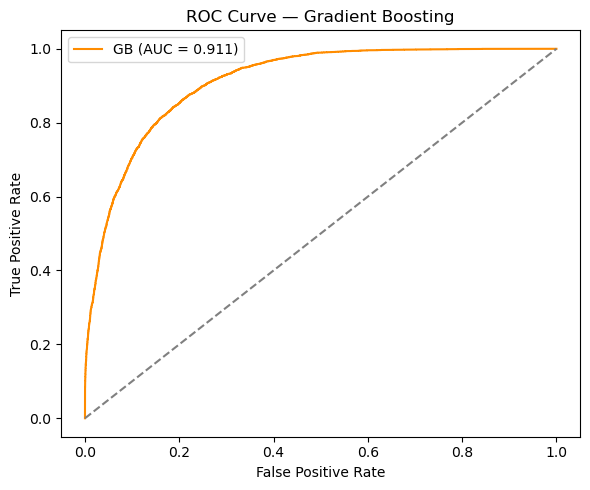

In [17]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'GB (AUC = {roc_auc:.3f})', color='darkorange')
plt.plot([0,1],[0,1],'--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Gradient Boosting')
plt.legend()
plt.tight_layout()
plt.show()

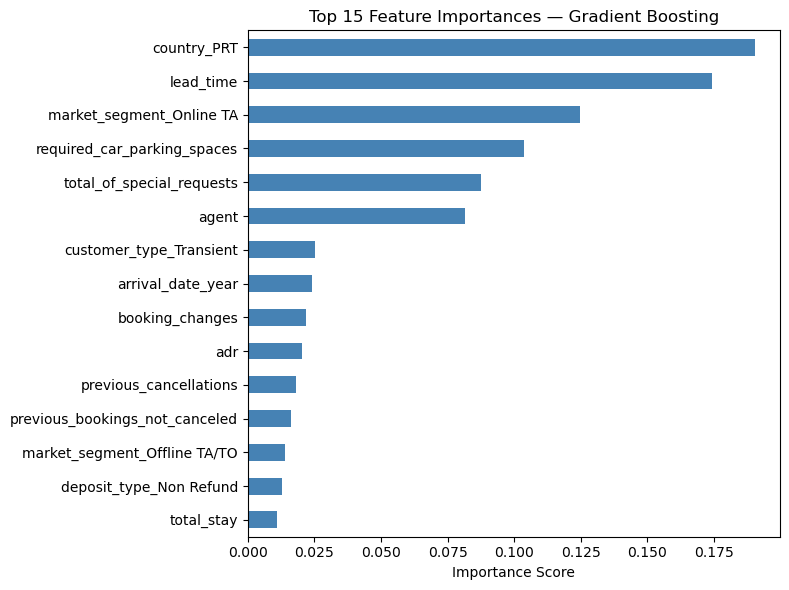

In [18]:
# Feature Importance (top 15)
feat_imp = pd.Series(gb_model.feature_importances_, index=X_train.columns)
feat_imp.nlargest(15).sort_values().plot(kind='barh', figsize=(8,6), color='steelblue')
plt.title('Top 15 Feature Importances — Gradient Boosting')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [34]:
# ==================
# CUSTOM PREDICTION
# ==================

import numpy as np
import pandas as pd

# Step 1: Define custom booking details
custom_input = {
    'hotel': 'Resort Hotel',
    'lead_time': 45,
    'arrival_date_year': 2017,
    'arrival_date_month': 'October',
    'arrival_date_week_number': 41,
    'arrival_date_day_of_month': 9,
    'stays_in_weekend_nights': 2,
    'stays_in_week_nights': 2,
    'adults': 2,
    'children': 0.0,
    'babies': 0,
    'meal': 'HB',
    'country': 'PRT',
    'market_segment': 'Direct',
    'distribution_channel': 'Direct',
    'is_repeated_guest': 1,
    'previous_cancellations': 0,
    'previous_bookings_not_canceled': 8,
    'reserved_room_type': 'C',
    'assigned_room_type': 'C',
    'booking_changes': 0,
    'deposit_type': 'No Deposit',
    'agent': 0.0,
    'days_in_waiting_list': 0,
    'customer_type': 'Transient',
    'adr': 160.0,
    'required_car_parking_spaces': 1,
    'total_of_special_requests': 3
}

# Step 2: Convert to DataFrame
custom_df = pd.DataFrame([custom_input])

# Step 3: Apply the same feature engineering as training
custom_df['total_stay']   = custom_df['stays_in_weekend_nights'] + custom_df['stays_in_week_nights']
custom_df['total_guests'] = custom_df['adults'] + custom_df['children'] + custom_df['babies']
custom_df['has_agent']    = (custom_df['agent'] > 0).astype(int)

# Step 4: Group rare countries → "Other" (same logic as training)
custom_df['country'] = custom_df['country'].where(custom_df['country'].isin(top_countries), 'Other')

# Step 5: One-hot encode
custom_df = pd.get_dummies(custom_df)

# Step 6: Align columns to match training data exactly
custom_df = custom_df.reindex(columns=X_train.columns, fill_value=0)

# Step 7: Predict
prediction  = gb_model.predict(custom_df)[0]
probability = gb_model.predict_proba(custom_df)[0]

# Step 8: Display result
print("=" * 40)
print("       BOOKING PREDICTION RESULT")
print("=" * 40)
if prediction == 1:
    print("⚠️  Prediction : WILL CANCEL")
else:
    print("✅  Prediction : WILL NOT CANCEL")

print(f"\n   Probability of NOT cancelling : {probability[0]*100:.1f}%")
print(f"   Probability of CANCELLING     : {probability[1]*100:.1f}%")
print("=" * 40)

       BOOKING PREDICTION RESULT
✅  Prediction : WILL NOT CANCEL

   Probability of NOT cancelling : 99.8%
   Probability of CANCELLING     : 0.2%
